In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from pymargins import Margins

rng = np.random.default_rng(42)
n = 600
df = pd.DataFrame({
    "age": rng.integers(20, 75, n),
    "female": rng.binomial(1, 0.52, n),
    "treated": rng.binomial(1, 0.40, n),
    "site": rng.choice(["A", "B", "C", "D"], n),
    "subject": np.repeat(np.arange(60), 10),
})
lp = -1.5 + 0.04 * df["age"] - 0.3 * df["female"] + 0.8 * df["treated"]
df["y"] = rng.binomial(1, 1 / (1 + np.exp(-lp)))

fit = smf.gee(
    "y ~ age + female + treated + C(site)",
    groups="subject",
    data=df,
    family=sm.families.Binomial(),
    cov_struct=sm.cov_struct.Independence(),
).fit()

In [2]:
m = Margins.linear_scale(fit, at="overall")
print(m.dydx("age").summary())

           Margins Result (delta, level=0.95)          
     estimate  std err       z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------
age    0.0095   0.0016  6.0065  0.000    0.0064, 0.0126

n = 600
κ: 0.073
Delta-vs-sim disagreement: 11.886%


In [3]:
print(m.predict(atexog={"treated": [0, 1]}).summary())

              Margins Result (delta, level=0.95)              
           estimate  std err        z  P>|z|  [95% Conf. Int.]
--------------------------------------------------------------
treated=0    0.5450   0.0201  27.1783  0.000    0.5057, 0.5843
treated=1    0.7111   0.0295  24.1027  0.000    0.6533, 0.7689

n = 600
κ: max=0.062
Delta-vs-sim disagreement: 0.744%


In [4]:
from pymargins import pairwise

scen, w = pairwise("treated", [1, 0])
print(m.contrasts(scenarios=scen, contrasts=w).summary())

              Margins Result (delta, level=0.95)             
           estimate  std err       z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------------
treated=1    0.1661   0.0374  4.4473  0.000    0.0929, 0.2393

n = 600
κ: 0.053
Delta-vs-sim disagreement: 3.928%


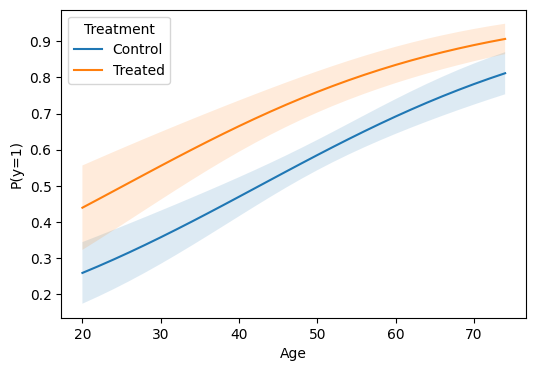

In [5]:
import matplotlib.pyplot as plt

ages = list(range(20, 76, 2))
res = m.predict(atexog={"age": ages, "treated": [0, 1]})
df_plot = res.to_frame()

fig, ax = plt.subplots(figsize=(6, 4))
for level, sub in df_plot.groupby("treated"):
    label = "Treated" if level == 1 else "Control"
    ax.plot(sub["age"], sub["estimate"], label=label)
    ax.fill_between(
        sub["age"], sub["ci_lower"], sub["ci_upper"], alpha=0.15
    )
ax.set(xlabel="Age", ylabel="P(y=1)")
ax.legend(title="Treatment")

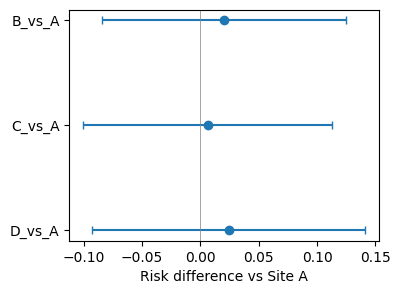

In [6]:
from pymargins import reference

scen, W = reference("site", ["A", "B", "C", "D"], ref_level="A")
res = m.contrasts(scenarios=scen, contrasts=W)
df_forest = res.to_frame()

fig, ax = plt.subplots(figsize=(4, 3))
y = range(len(df_forest))
ax.errorbar(
    df_forest["estimate"], y,
    xerr=[df_forest["estimate"] - df_forest["ci_lower"],
          df_forest["ci_upper"] - df_forest["estimate"]],
    fmt="o", capsize=3,
)
ax.axvline(0, color="grey", lw=0.5)
ax.set_yticks(list(y))
ax.set_yticklabels(df_forest["label"])
ax.set_xlabel("Risk difference vs Site A")
ax.invert_yaxis()

In [7]:
# Naive (model-based) covariance
m_naive = Margins.linear_scale(fit, vcov="naive", at="overall")
print(m_naive.dydx("age").summary())

# Bias-corrected robust sandwich (if available)
try:
    m_bc = Margins.linear_scale(fit, vcov="robust_bc", at="overall")
    print(m_bc.dydx("age").summary())
except ValueError as exc:
    print("robust_bc not available:", exc)

           Margins Result (delta, level=0.95)          
     estimate  std err       z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------
age    0.0095   0.0013  7.1816  0.000    0.0069, 0.0121

n = 600
κ: 0.063
Delta-vs-sim disagreement: 9.331%
robust_bc not available: cov_robust_bc is not available on this fit.
